# REPLICATE SAMPLE ANALYSIS

## Purpose

Replicate samples are used to assess analytical consistency and repeatability within the same analytical scheme or testing context.

## Data Characteristics

- Paired or repeated observations within a single scheme
- Focused on repeatability under similar analytical conditions
- Derived precision features may include:
  - Absolute Difference (ABS_DIFF)
  - Relative Percent Difference (RPD)
  - Mean Concentration (MEAN_CONC)
- May exhibit concentration-dependent variability

## Typical Anomaly Patterns

- **Within-scheme inconsistencies**  
  Unexpected variation between replicate measurements

- **Temporal anomalies**  
  Repeatability degradation over time within the same scheme

- **Conditional anomalies**  
  Elevated variability under specific analytical conditions

## Interpretation

Replicate anomalies may indicate:

- Inconsistent analytical execution
- Instrument calibration drift
- Environmental or operational instability
- Scheme-specific processing issues

## Analytical Relevance

Replicate QC data supports:

- Repeatability analysis
- Within-scheme precision assessment
- Statistical deviation monitoring
- Anomaly detection within controlled analytical contexts

## QC Rule Context

`PRECISION_STATUS` represents an existing rule-based QC classification.

This notebook investigates whether unsupervised learning methods can identify additional anomalous behaviour beyond predefined QC thresholds.

## Duplicate vs Replicate Samples

According to domain guidance provided by Dion:

> "Duplicates duplicate across all schemes whereas replicates are duplicated only within one scheme."

Operational activities marked as "ignored" are generally user-driven manual processes rather than automated system events.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest


In [2]:
df = pd.read_csv(
    "../data/raw/ResultSet.csv",
    dtype={"INSTRUMENT_ID": "string"}
)

df.head()


,ANALYTICAL_TYPE,STD_LOT_CODE,STD_CODE,JOB_CODE,NUMERIC_FINAL_VALUE,ANALYSED_DATE,SCHEME_CODE,ANALYTE_CODE,STANDARD_STATUS,PRECISION_STATUS,...,INTERNAL_MAX_WARNING_INCLUSIVE,LIM_REP_VALUE,STAT_DL_VALUE,LIM_REP_DUP_VALUE,STAT_DL_DUP_VALUE,INTERNAL_TARGET_VALUE,PARENT_NUMERIC_FINAL_VALUE,UNIT_CODE,SPECIFICATION_CODE,INSTRUMENT_ID
0,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,35.927171,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,...,Y,10,1.25,15.0,1.25,30.40,NaN,MG_KG,OREAS_905,<NA>
1,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,55.639610,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,UpperFailure,NaN,...,Y,10,1.25,15.0,1.25,30.40,NaN,MG_KG,OREAS_905,<NA>
2,Replicate,Sample,Sample,TSV_LB0016663011,1492.268392,2021-11-22 16:37:52.000000,GE_IMS40Q12,PB,NaN,Warning,...,NaN,10,1.25,15.0,1.25,NaN,1385.198107,MG_KG,NaN,<NA>
3,Replicate,Sample,Sample,TSV_LB0016663011,18.525452,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,NaN,Pass,...,NaN,10,5.00,15.0,5.00,NaN,16.334782,MG_KG,NaN,<NA>
4,Standard,OREAS_905,OREAS_905,TSV_LB0016663011,11.742601,2021-11-22 16:37:33.000000,GE_IMS40Q12,NI,UpperWarning,NaN,...,Y,10,5.00,15.0,5.00,9.54,NaN,MG_KG,OREAS_905,<NA>


## Column Selection - Replicates

**ANALYTICAL_TYPE == 'Duplicate'**

**STD_LOT_CODE == 'Sample'**

**STD_CODE == 'Sample'**

**JOB_CODE == 'TSV_LB000\*'**

Conforms to label format.

**NUMERIC_FINAL_VALUE**

The NUMERIC_FINAL_VALUE represents the measured concentration for duplicate sample analyses. Summary statistics indicate a highly skewed distribution:

The mean (≈ 60.0) is substantially higher than the median (≈ 6.54), suggesting the presence of extreme high-value outliers.
The maximum value (≈ 16,778) is several orders of magnitude larger than the upper quartile (75% ≈ 30.17), reinforcing that a small number of large observations are heavily influencing the distribution.

The standard deviation (≈ 315.1) is also very large relative to the median, further indicating high variability driven by outliers.
There is a presence of negative values (min ≈ -43.7).

Overall, the distribution is right-skewed - Precision varies with concentration?

**ANALYSED_DATE**

Datetime

**SCHEME_CODE == 'GE_ICP40Q12'**

**ANALYTE_CODE**

`TA, TE, MO, CE, S, ZR, V, W, Y, CR, BE, CD, BA, TH, SN, SE, SC, NI, NB, LI, LA, HF, U, ZN, TI, PB, RB, MN, MG, CO, SR, CA, BI, AL, FE, SB, CU, K, P, AG, AS`

**STANDARD_STATUS** (nan)

**PRECISION_STATUS**

`Warning, Pass, IgnoreFailure, Failure`

**INTERNAL_MIN_VALUE** (nan)

**INTERNAL_MAX_VALUE** (nan)

**INTERNAL_MIN_INCLUSIVE**

**INTERNAL_MAX_INCLUSIVE** (nan)

**INTERNAL_MAX_WARNING_VALUE** (nan)

**INTERNAL_MIN_WARNING_VALUE** (nan)

**INTERNAL_MIN_WARNING_INCLUSIVE** (nan)

**INTERNAL_MAX_WARNING_INCLUSIVE** (nan)

**LIM_REP_VALUE (Replicate Only)**

`10 or 15`

**STAT_DL_VALUE (Replicate Only)**

`0.025, 1.25, 2.5, 5.0, 7.5, 12.5, 25.0, 50.0`

**LIM_REP_DUP_VALUE (Duplicate Only)**

`15.0`

**STAT_DL_DUP_VALUE (Duplicate Only)**

`0.025, 0.25, 1.25, 2.5, 5, 7.5, 12.5, 25, 50`

**INTERNAL_TARGET_VALUE** (nan)


**PARENT_NUMERIC_FINAL_VALUE**

Parent measurement?

Summary stats:

The mean (≈ 60.25) is substantially higher than the median (≈ 6.76), indicating the presence of high-value outliers that are inflating the average.
The maximum value (≈ 16,881) is several orders greater than the upper quartile (75% ≈ 30.60), confirming a long right tail.
The standard deviation (≈ 315.99) is large relative to the median.
The minimum value (≈ -58.80)?
There are no missing values.

The distribution is right-skewed - Variability increases with concentration?

**UNIT_CODE**

`MG_KG, PERC`

**SPECIFICATION_CODE** (nan)

**INSTRUMENT_ID** (nan)


In [15]:
replicate_cols = [
    "NUMERIC_FINAL_VALUE",         # Duplicate measurement (primary observed value)
    "PARENT_NUMERIC_FINAL_VALUE",  # Original measurement (paired with duplicate)
    "ANALYSED_DATE",               # Temporal feature
    "ANALYTE_CODE",                # Element/compound being measured
    "STAT_DL_VALUE",               # Detection limit for original sample (affects low-end variability)
    "LIM_REP_VALUE",               # Reporting limit for original sample (rounding/threshold effects)
    "UNIT_CODE",                   # Measurement unit (e.g. MG_KG)
    "PRECISION_STATUS"             # Rule-based QC classification (Pass/Warning/Failure)
]

In [5]:
# Filter replicates AND select only important columns
df_replicates = df[
    df["ANALYTICAL_TYPE"].str.strip().str.lower() == "replicate"
][replicate_cols].copy()

# Export to CSV
df_replicates.to_csv("../data/processed/replicates_only.csv", index=False)


## Intermediate Model

Build model for both duplicates and replicates with the following derived columns added:
Add Absoulute difference
Mean of X1 and X2
RPD calculated from absolute difference and the mean of the duplciate/parent values.


In [7]:
def build_replicate_model(df_input):
    """
    Build a modelling-ready dataset for QC precision analysis.

    Derives pairwise features between a QC sample (duplicate/replicate)
    and its parent sample:
        - ABS_DIFF   : Absolute difference
        - MEAN_CONC  : Mean concentration
        - RPD        : Relative Percent Difference (rounded to 2 d.p.)

    Notes:
        - Handles divide-by-zero using np.nan
        - Designed for duplicate and replicate samples
    """
    
    df_model = df_input.copy()

    # Absolute difference
    df_model["ABS_DIFF"] = abs(
        df_model["NUMERIC_FINAL_VALUE"] - df_model["PARENT_NUMERIC_FINAL_VALUE"]
    )

    # Mean concentration
    df_model["MEAN_CONC"] = (
        df_model["NUMERIC_FINAL_VALUE"] + df_model["PARENT_NUMERIC_FINAL_VALUE"]
    ) / 2

    # Relative Percent Difference (RPD)
    df_model["RPD"] = np.where(
        # TODO: Add more validation around average conc being very close to zero or equal to zero - Maybe exclude record...
        (df_model["NUMERIC_FINAL_VALUE"] + df_model["PARENT_NUMERIC_FINAL_VALUE"]) != 0,
        df_model["ABS_DIFF"] / df_model["MEAN_CONC"] * 100,
        np.nan
    )

    # Round to 2 decimal places (still float)
    df_model["RPD"] = df_model["RPD"].round(2)

    # Final column order
    df_model = df_model[
        [
            "ANALYSED_DATE",
            "ANALYTE_CODE",
            "PARENT_NUMERIC_FINAL_VALUE",
            "NUMERIC_FINAL_VALUE",
            "STAT_DL_VALUE",
            "MEAN_CONC",
            "ABS_DIFF",
            "RPD",
            "PRECISION_STATUS",
            "LIM_REP_VALUE",
            "UNIT_CODE"
        ]
    ]

    return df_model
    

In [8]:
df_replicates_model = build_replicate_model(df_replicates)


In [9]:
df_replicates_model.to_csv("../data/processed/replicates_model.csv", index=False)


In [10]:
df_replicates_model.head(10)


,ANALYSED_DATE,ANALYTE_CODE,PARENT_NUMERIC_FINAL_VALUE,NUMERIC_FINAL_VALUE,STAT_DL_VALUE,MEAN_CONC,ABS_DIFF,RPD,PRECISION_STATUS,LIM_REP_VALUE,UNIT_CODE
2,2021-11-22 16:37:52.000000,PB,1385.198107,1492.268392,1.250,1438.733250,107.070285,7.44,Warning,10,MG_KG
3,2021-11-22 16:37:33.000000,NI,16.334782,18.525452,5.000,17.430117,2.190670,12.57,Pass,10,MG_KG
9,2021-11-22 16:35:49.000000,AG,14.647905,14.901179,0.050,14.774542,0.253274,1.71,Pass,10,MG_KG
14,2021-11-22 16:35:49.000000,CU,18891.143085,19641.928358,5.000,19266.535721,750.785274,3.90,Pass,10,MG_KG
15,2021-11-22 16:35:49.000000,ZN,2340.890959,2419.042385,12.500,2379.966672,78.151426,3.28,Pass,10,MG_KG
20,2021-11-10 07:12:48.000000,BE,0.216041,0.220098,0.250,0.218070,0.004057,1.86,Pass,10,MG_KG
21,2021-11-10 07:12:48.000000,BE,0.156735,0.187723,0.250,0.172229,0.030988,17.99,Pass,10,MG_KG
25,2021-11-10 07:12:38.000000,MO,357.062846,358.962758,0.125,358.012802,1.899912,0.53,Pass,10,MG_KG
29,2021-11-10 07:12:38.000000,MO,359.480473,351.878831,0.125,355.679652,7.601642,2.14,Pass,10,MG_KG
31,2021-11-10 07:11:51.000000,SB,137.521696,161.816372,0.125,149.669034,24.294676,16.23,IgnoreFailure,10,MG_KG


In [22]:
# =========================================================
# Plot duplicate precision analysis by analyte
# =========================================================
def plot_analyte_rpd(
    df,
    analyte,
    x_col="MEAN_CONC",
    y_col="RPD",
    log_x=False,
    y_max=None,
    show_detection_limit=True,
    include_ignore_failures=True,
    figsize=(8, 5)
):
    """
    Plot duplicate precision analysis for a single analyte.

    Features:
    - Colour-coded PRECISION_STATUS
    - Horizontal reproducibility limit
    - Optional vertical statistical detection limit
    - Optional exclusion of IgnoreFailure records
    """

    import matplotlib.pyplot as plt

    # Filter analyte
    df_plot = df[
        df["ANALYTE_CODE"] == analyte
    ].copy()

    # Optional IgnoreFailure exclusion
    if not include_ignore_failures:

        df_plot = df_plot[
            df_plot["PRECISION_STATUS"] != "IgnoreFailure"
        ]

    # Remove invalid rows
    df_plot = df_plot[
        (df_plot[x_col] > 0) &
        (~df_plot[y_col].isna()) &
        (~df_plot["LIM_REP_VALUE"].isna())
    ]

    # Reproducibility limit
    limit_value = df_plot["LIM_REP_VALUE"].iloc[0]

    # Statistical detection limit
    stat_dl_value = None

    if "STAT_DL_VALUE" in df_plot.columns:

        stat_values = df_plot["STAT_DL_VALUE"].dropna()

        if len(stat_values) > 0:
            stat_dl_value = stat_values.iloc[0]

    # Status colour mapping
    status_colors = {
        "Pass": "green",
        "Warning": "orange",
        "Failure": "red",
        "IgnoreFailure": "grey"
    }

    # Create figure
    plt.figure(figsize=figsize)

    # Plot each status separately
    for status, color in status_colors.items():

        # Skip IgnoreFailure if excluded
        if (
            status == "IgnoreFailure"
            and not include_ignore_failures
        ):
            continue

        df_status = df_plot[
            df_plot["PRECISION_STATUS"] == status
        ]

        if len(df_status) > 0:

            plt.scatter(
                df_status[x_col],
                df_status[y_col],
                alpha=0.7,
                color=color,
                label=f"{status} ({len(df_status)})"
            )

    # Horizontal reproducibility threshold
    plt.axhline(
        y=limit_value,
        linestyle="--",
        linewidth=2,
        color="black",
        label=f"RPD Limit ({limit_value:.1f}%)"
    )

    # Vertical statistical detection limit
    if show_detection_limit and stat_dl_value is not None:

        plt.axvline(
            x=stat_dl_value,
            linestyle=":",
            linewidth=2,
            color="blue",
            label=f"STAT_DL ({stat_dl_value:.3f})"
        )

    # Optional log scale
    if log_x:
        plt.xscale("log")

    # Optional y-axis cap
    if y_max is not None:
        plt.ylim(0, y_max)

    # Labels
    plt.xlabel("Mean Concentration")
    plt.ylabel("RPD (%)")
    plt.title(f"{analyte} Duplicate Precision Analysis")

    # Grid and legend
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Summary statistics
    print(f"Analyte: {analyte}")
    print(f"Total Points: {len(df_plot)}")

    print("\nPrecision Status Counts:")
    print(
        df_plot["PRECISION_STATUS"]
        .value_counts()
        .to_string()
    )

    if stat_dl_value is not None:
        print(f"\nSTAT_DL_VALUE: {stat_dl_value}")

    print(f"RPD Limit: {limit_value}")

    plt.show()
    

In [23]:
analyte_list = [
    "TA", "TE", "MO", "CE", "S", "ZR", "V", "W", "Y", "CR",
    "BE", "CD", "BA", "TH", "SN", "SE", "SC", "NI", "NB", "LI",
    "LA", "HF", "U", "ZN", "TI", "PB", "RB", "MN", "MG", "CO",
    "SR", "CA", "BI", "AL", "FE", "SB", "CU", "K", "P", "AG", "AS"
]



Analyte: TA
Total Points: 178

Precision Status Counts:
PRECISION_STATUS
Pass       164
Warning     12
Failure      2

STAT_DL_VALUE: 0.125
RPD Limit: 15


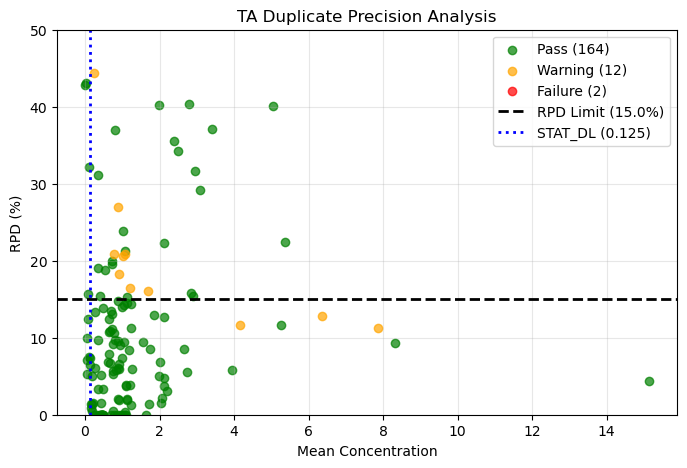


Analyte: TE
Total Points: 1681

Precision Status Counts:
PRECISION_STATUS
Pass       1634
Warning      47

STAT_DL_VALUE: 0.125
RPD Limit: 10


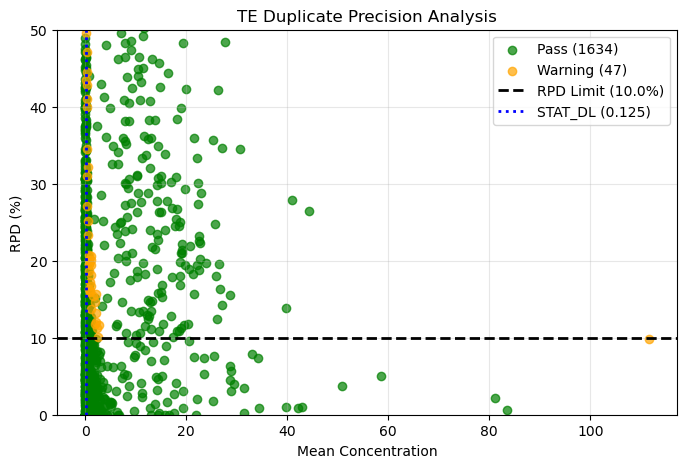


Analyte: MO
Total Points: 1782

Precision Status Counts:
PRECISION_STATUS
Pass       1554
Warning     206
Failure      22

STAT_DL_VALUE: 0.125
RPD Limit: 10


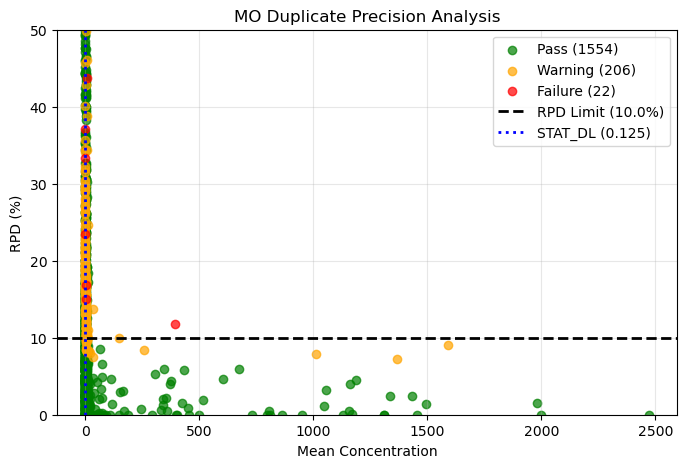


Analyte: CE
Total Points: 305

Precision Status Counts:
PRECISION_STATUS
Pass       248
Warning     37
Failure     20

STAT_DL_VALUE: 0.125
RPD Limit: 10


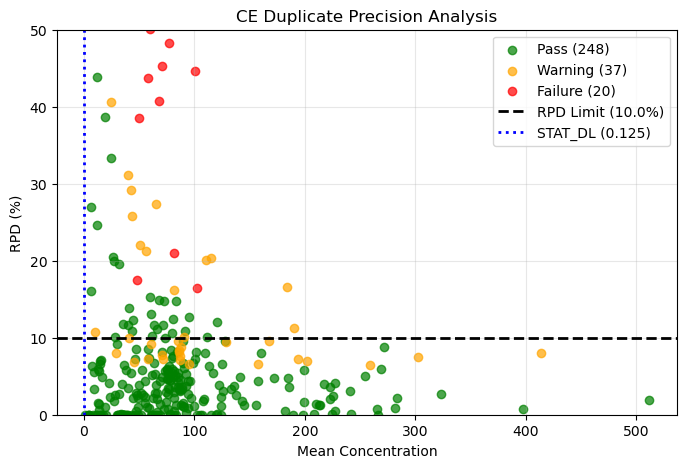


Analyte: S
Total Points: 1373

Precision Status Counts:
PRECISION_STATUS
Pass       1288
Warning      78
Failure       7

STAT_DL_VALUE: 0.025
RPD Limit: 10


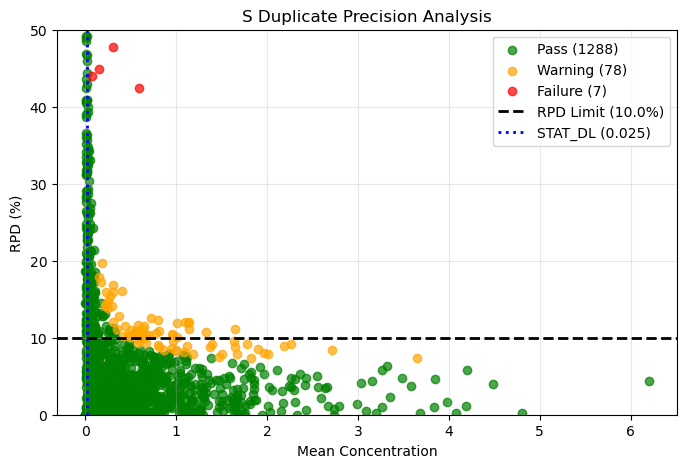


Analyte: ZR
Total Points: 269

Precision Status Counts:
PRECISION_STATUS
Pass       210
Warning     40
Failure     19

STAT_DL_VALUE: 1.25
RPD Limit: 10


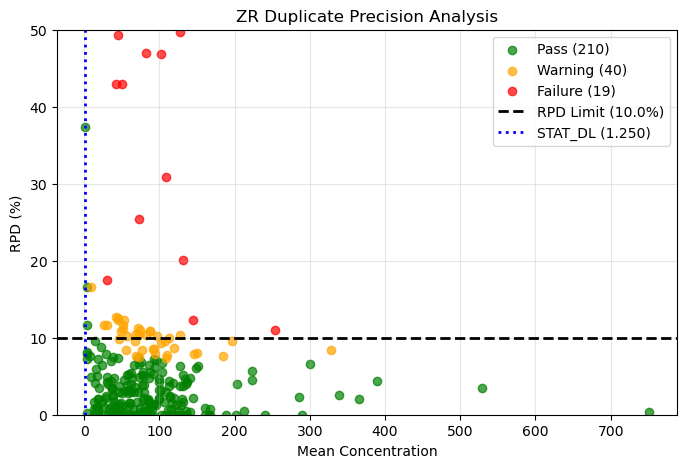


Analyte: V
Total Points: 428

Precision Status Counts:
PRECISION_STATUS
Pass       407
Warning     12
Failure      9

STAT_DL_VALUE: 5.0
RPD Limit: 10


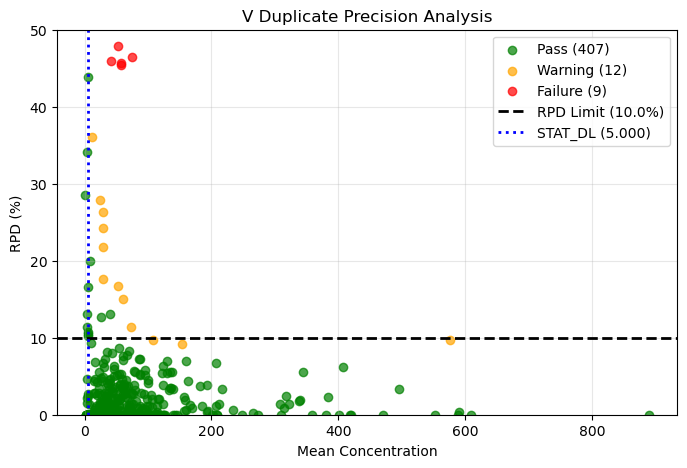


Analyte: W
Total Points: 1876

Precision Status Counts:
PRECISION_STATUS
Pass       1850
Warning      25
Failure       1

STAT_DL_VALUE: 0.25
RPD Limit: 15


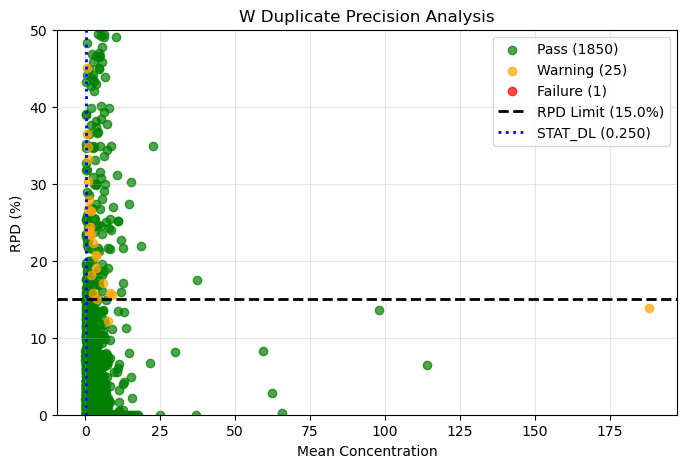


Analyte: Y
Total Points: 302

Precision Status Counts:
PRECISION_STATUS
Pass       268
Warning     18
Failure     16

STAT_DL_VALUE: 0.25
RPD Limit: 10


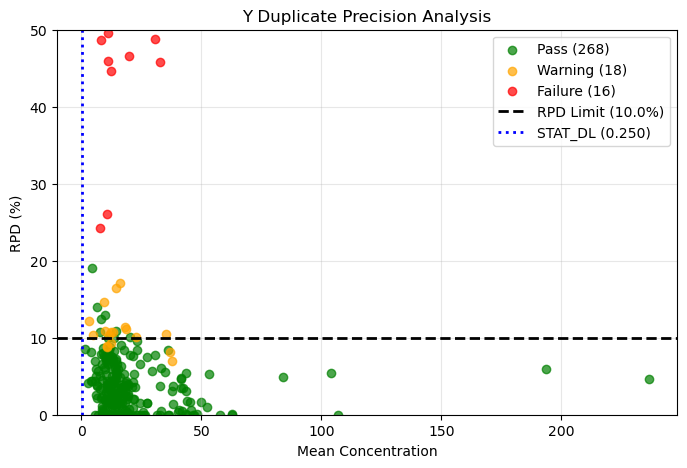


Analyte: CR
Total Points: 442

Precision Status Counts:
PRECISION_STATUS
Pass       385
Warning     40
Failure     17

STAT_DL_VALUE: 2.5
RPD Limit: 15


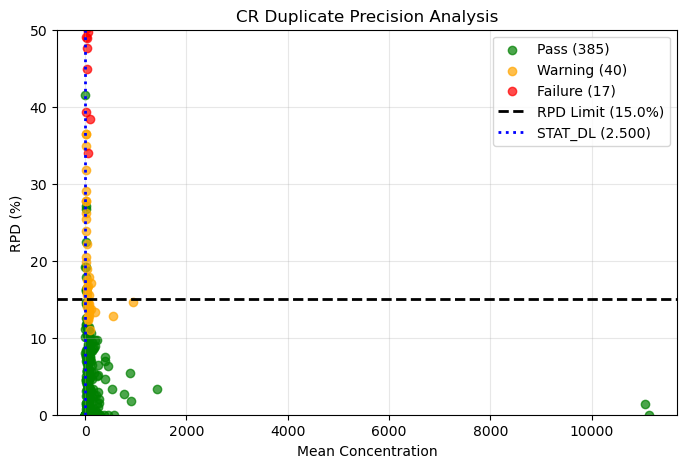


Analyte: BE
Total Points: 445

Precision Status Counts:
PRECISION_STATUS
Pass       426
Warning     19

STAT_DL_VALUE: 0.25
RPD Limit: 10


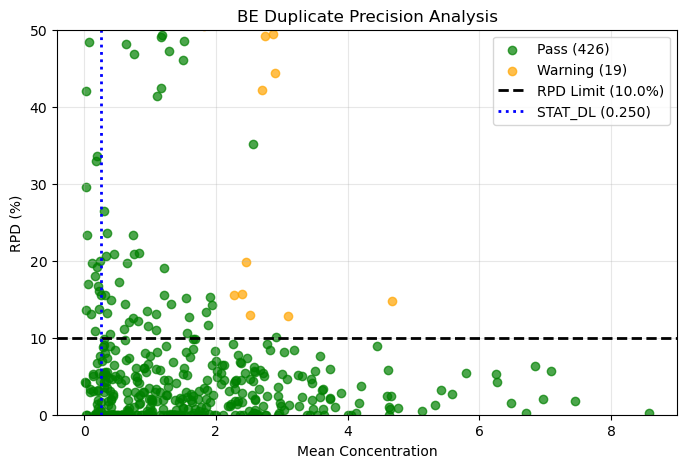


Analyte: CD
Total Points: 260

Precision Status Counts:
PRECISION_STATUS
Pass       235
Warning     25

STAT_DL_VALUE: 2.5
RPD Limit: 10


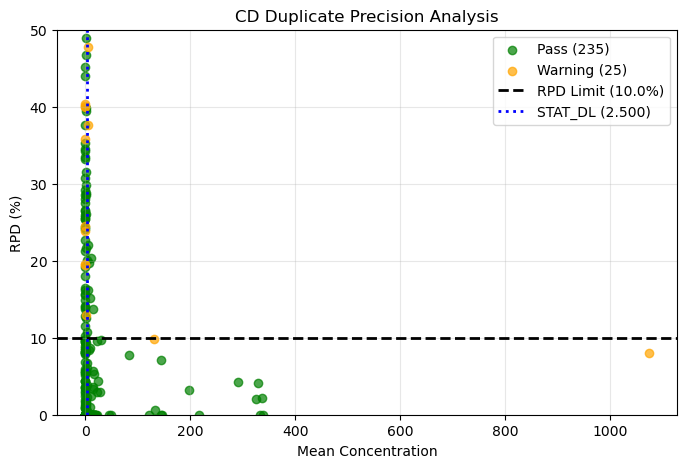


Analyte: BA
Total Points: 396

Precision Status Counts:
PRECISION_STATUS
Pass       344
Warning     44
Failure      8

STAT_DL_VALUE: 2.5
RPD Limit: 10


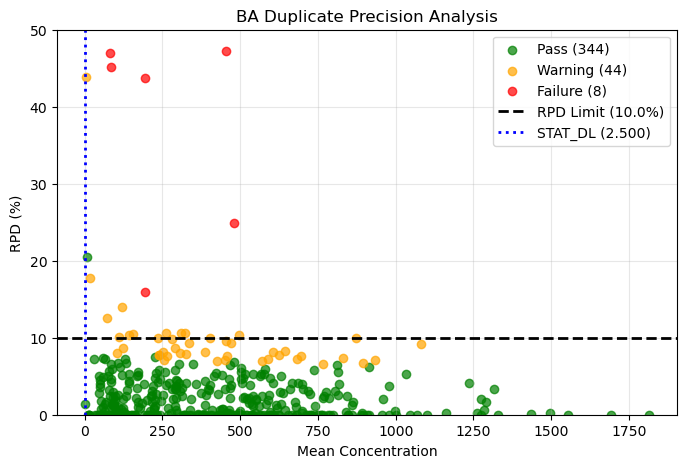


Analyte: TH
Total Points: 257

Precision Status Counts:
PRECISION_STATUS
Pass       233
Warning     16
Failure      8

STAT_DL_VALUE: 0.5
RPD Limit: 10


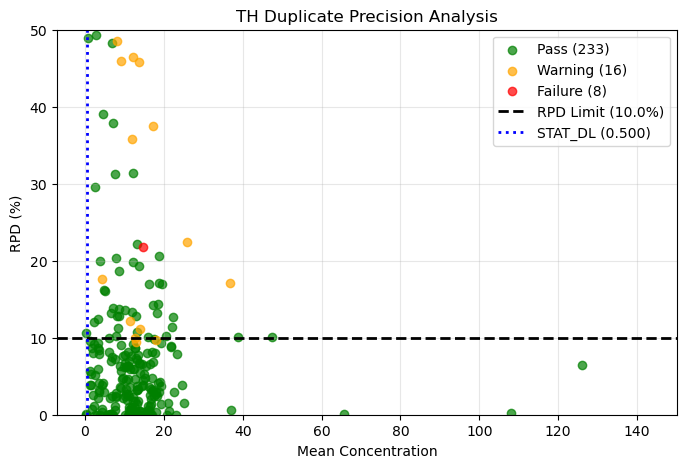


Analyte: SN
Total Points: 418

Precision Status Counts:
PRECISION_STATUS
Pass       398
Warning     19
Failure      1

STAT_DL_VALUE: 0.75
RPD Limit: 10


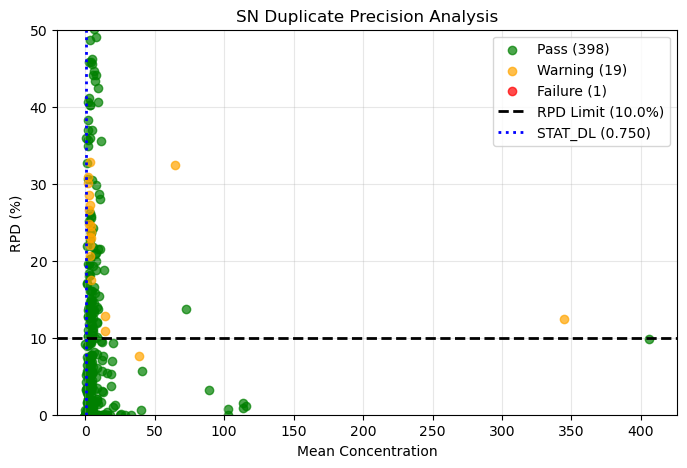


Analyte: SE
Total Points: 1834

Precision Status Counts:
PRECISION_STATUS
Pass       1778
Warning      51
Failure       5

STAT_DL_VALUE: 5.0
RPD Limit: 10


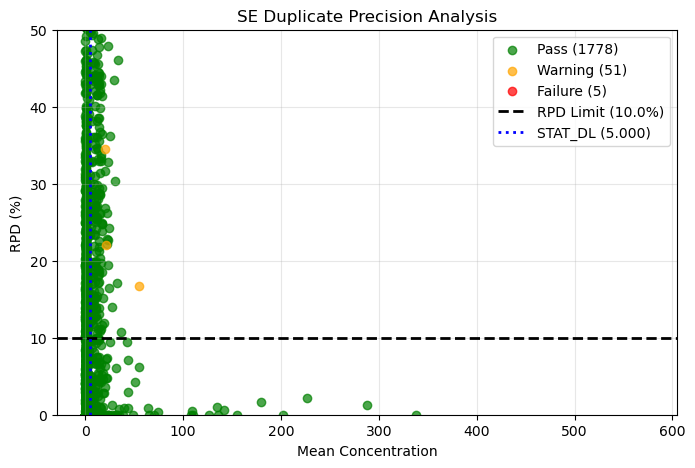


Analyte: SC
Total Points: 306

Precision Status Counts:
PRECISION_STATUS
Pass       274
Failure     18
Warning     14

STAT_DL_VALUE: 1.25
RPD Limit: 10


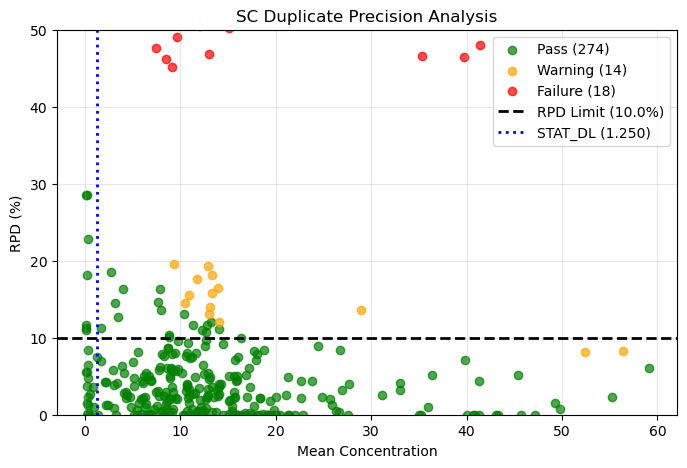


Analyte: NI
Total Points: 416

Precision Status Counts:
PRECISION_STATUS
Pass       334
Warning     51
Failure     31

STAT_DL_VALUE: 5.0
RPD Limit: 10


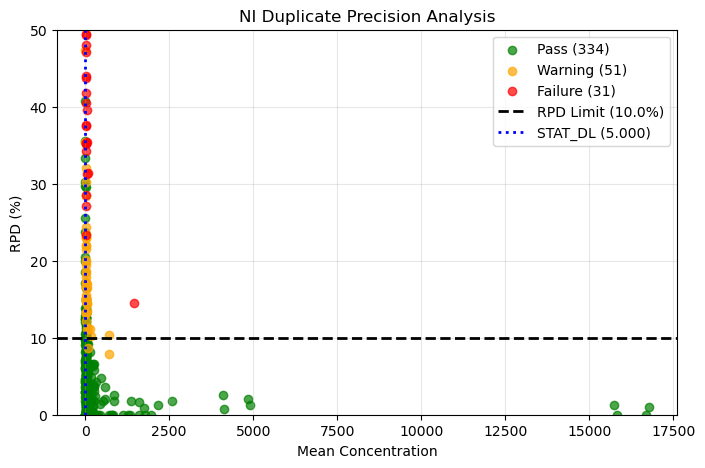


Analyte: NB
Total Points: 198

Precision Status Counts:
PRECISION_STATUS
Pass       167
Warning     28
Failure      3

STAT_DL_VALUE: 0.25
RPD Limit: 10


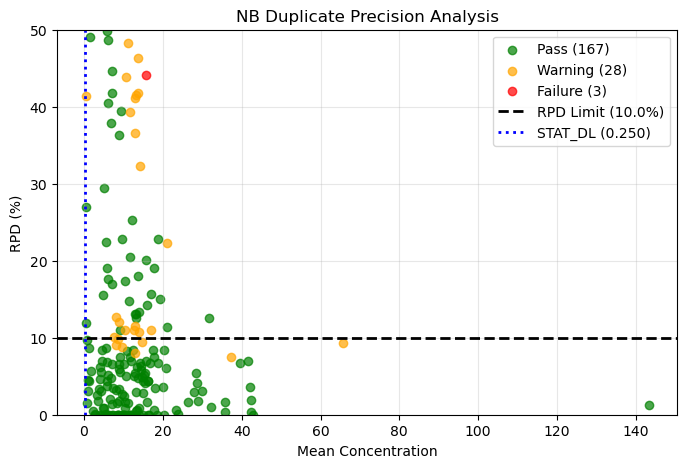


Analyte: LI
Total Points: 431

Precision Status Counts:
PRECISION_STATUS
Pass       389
Warning     30
Failure     12

STAT_DL_VALUE: 0.25
RPD Limit: 10


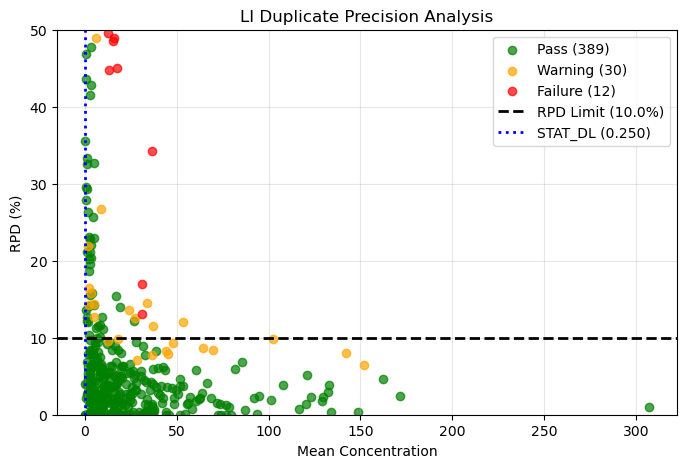


Analyte: LA
Total Points: 336

Precision Status Counts:
PRECISION_STATUS
Pass       276
Warning     38
Failure     22

STAT_DL_VALUE: 0.25
RPD Limit: 10


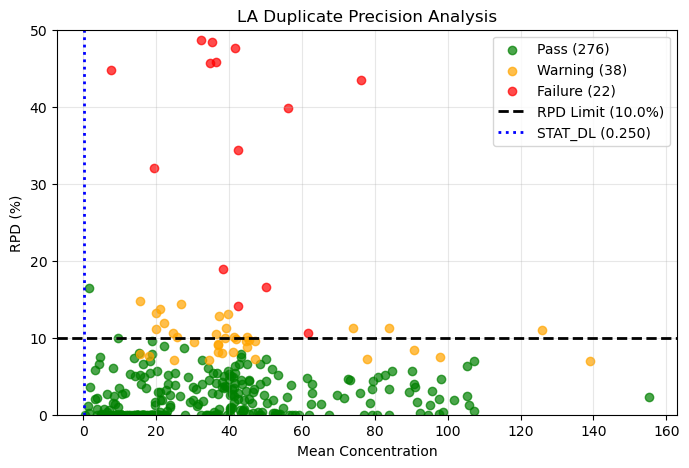


Analyte: HF
Total Points: 219

Precision Status Counts:
PRECISION_STATUS
Pass       186
Warning     27
Failure      6

STAT_DL_VALUE: 0.05
RPD Limit: 10


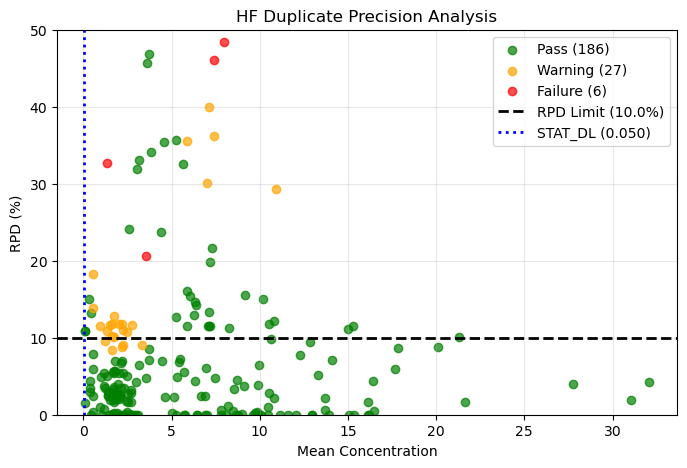


Analyte: U
Total Points: 248

Precision Status Counts:
PRECISION_STATUS
Pass       230
Warning     18

STAT_DL_VALUE: 0.125
RPD Limit: 10


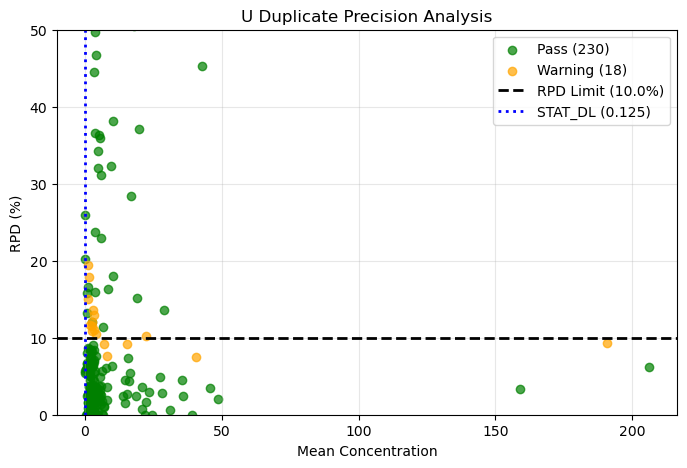


Analyte: ZN
Total Points: 2163

Precision Status Counts:
PRECISION_STATUS
Pass       1936
Warning     179
Failure      48

STAT_DL_VALUE: 12.5
RPD Limit: 10


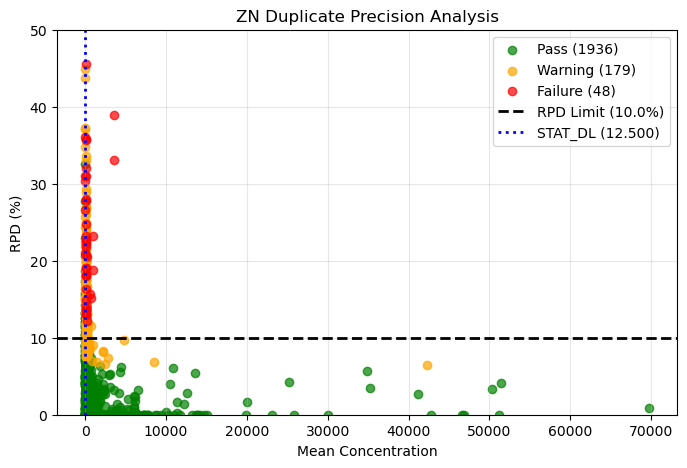


Analyte: TI
Total Points: 338

Precision Status Counts:
PRECISION_STATUS
Pass       303
Warning      7
Failure      2

STAT_DL_VALUE: 0.025
RPD Limit: 10


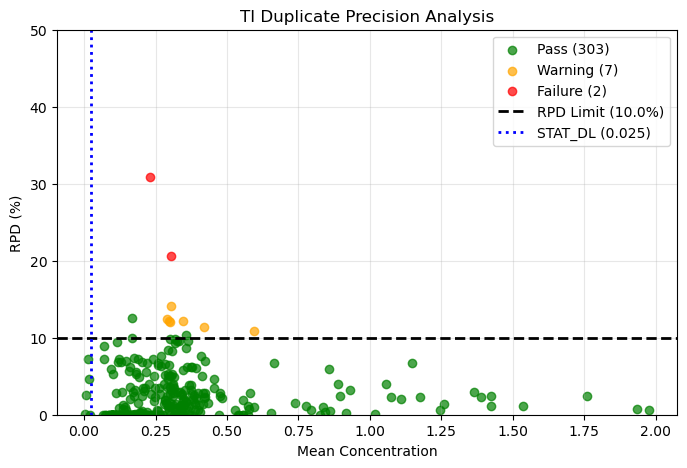


Analyte: PB
Total Points: 2010

Precision Status Counts:
PRECISION_STATUS
Pass       1821
Warning     155
Failure      34

STAT_DL_VALUE: 1.25
RPD Limit: 10


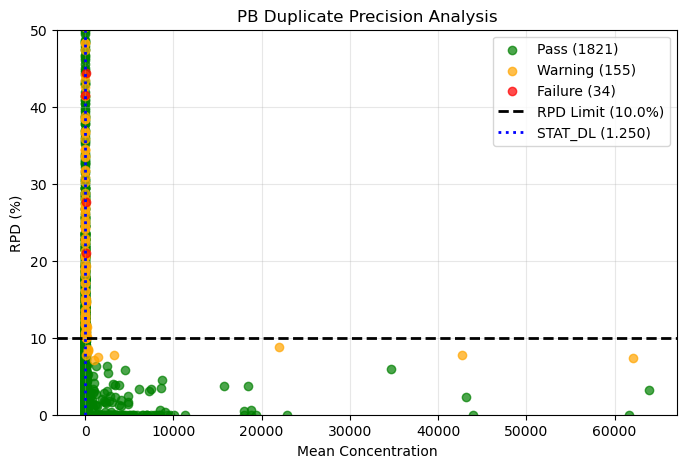


Analyte: RB
Total Points: 421

Precision Status Counts:
PRECISION_STATUS
Pass       388
Warning     27
Failure      6

STAT_DL_VALUE: 0.5
RPD Limit: 10


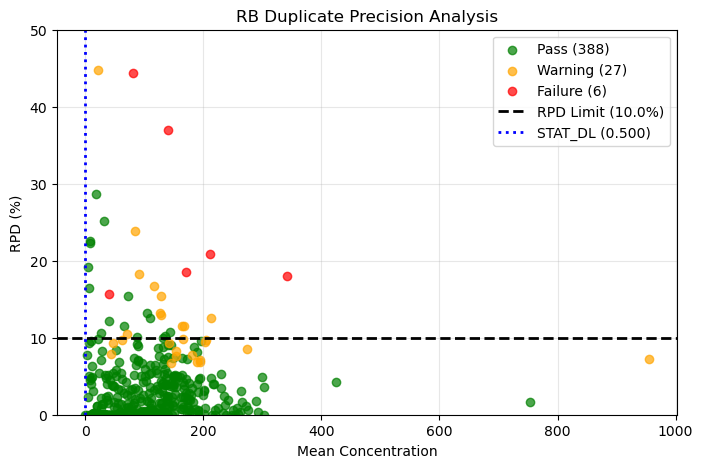


Analyte: MN
Total Points: 572

Precision Status Counts:
PRECISION_STATUS
Pass       529
Warning     40
Failure      3

STAT_DL_VALUE: 5.0
RPD Limit: 10


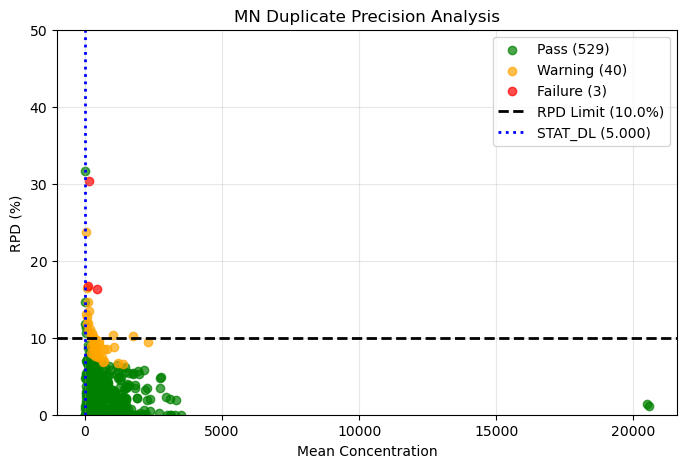


Analyte: MG
Total Points: 384

Precision Status Counts:
PRECISION_STATUS
Pass       364
Warning     17
Failure      3

STAT_DL_VALUE: 0.025
RPD Limit: 10


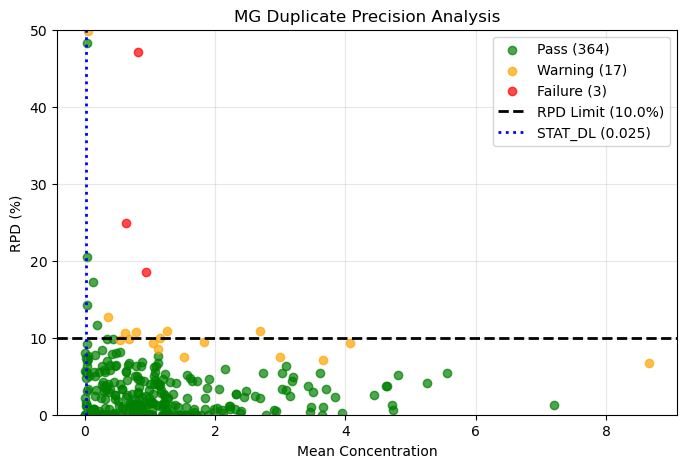


Analyte: CO
Total Points: 527

Precision Status Counts:
PRECISION_STATUS
Pass       449
Warning     66
Failure     12

STAT_DL_VALUE: 2.5
RPD Limit: 10


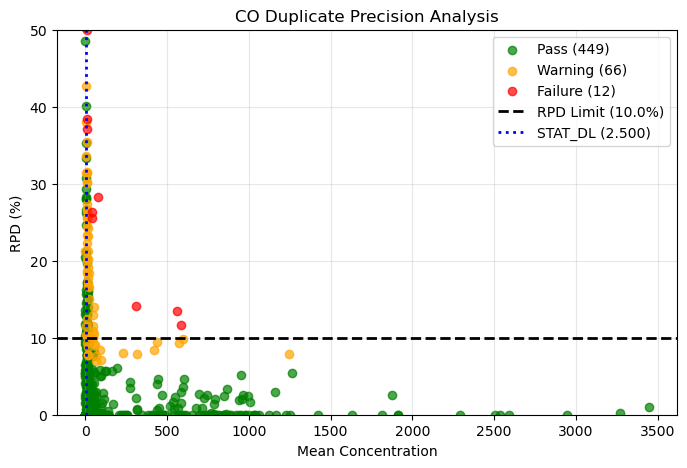


Analyte: SR
Total Points: 313

Precision Status Counts:
PRECISION_STATUS
Pass       253
Warning     53
Failure      7

STAT_DL_VALUE: 1.25
RPD Limit: 10


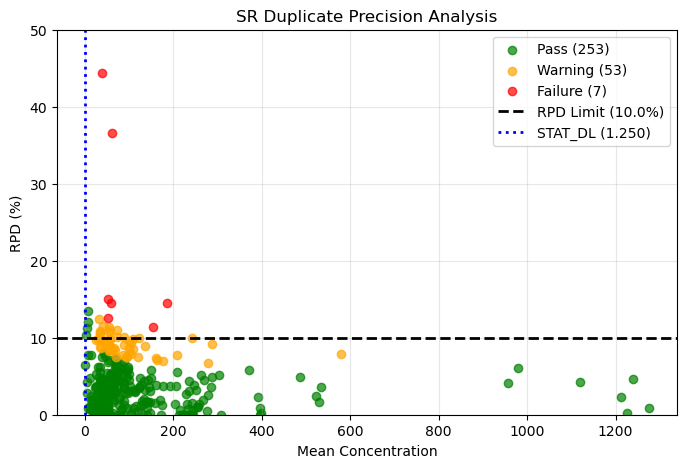


Analyte: CA
Total Points: 422

Precision Status Counts:
PRECISION_STATUS
Pass       410
Warning     11
Failure      1

STAT_DL_VALUE: 0.025
RPD Limit: 10


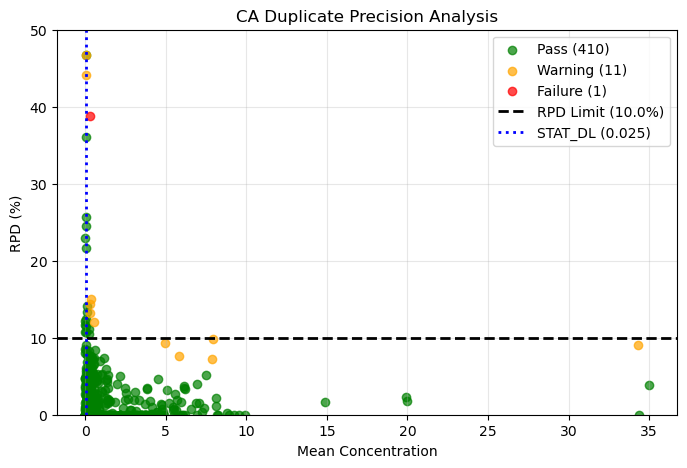


Analyte: BI
Total Points: 1480

Precision Status Counts:
PRECISION_STATUS
Pass       1409
Warning      70
Failure       1

STAT_DL_VALUE: 0.1
RPD Limit: 10


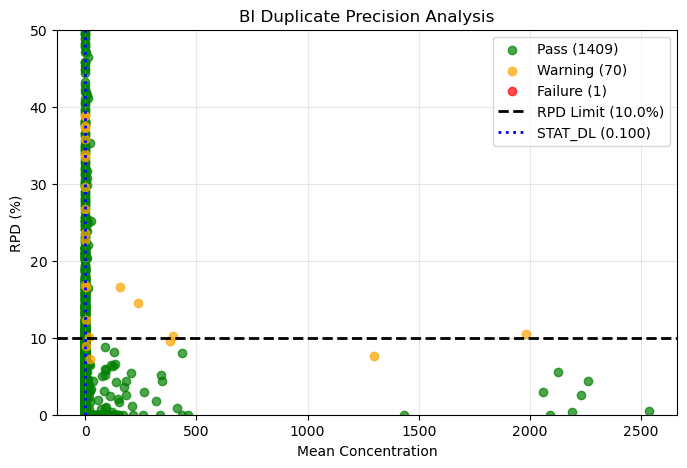


Analyte: AL
Total Points: 389

Precision Status Counts:
PRECISION_STATUS
Pass       372
Warning     16
Failure      1

STAT_DL_VALUE: 0.025
RPD Limit: 10


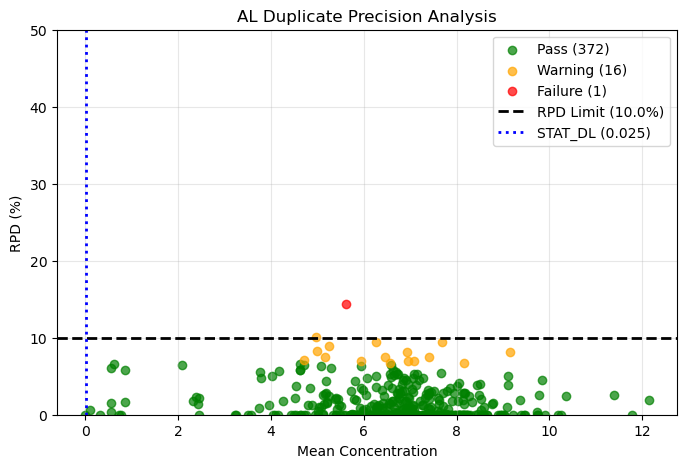


Analyte: FE
Total Points: 1425

Precision Status Counts:
PRECISION_STATUS
Pass       1302
Warning     121
Failure       2

STAT_DL_VALUE: 0.025
RPD Limit: 10


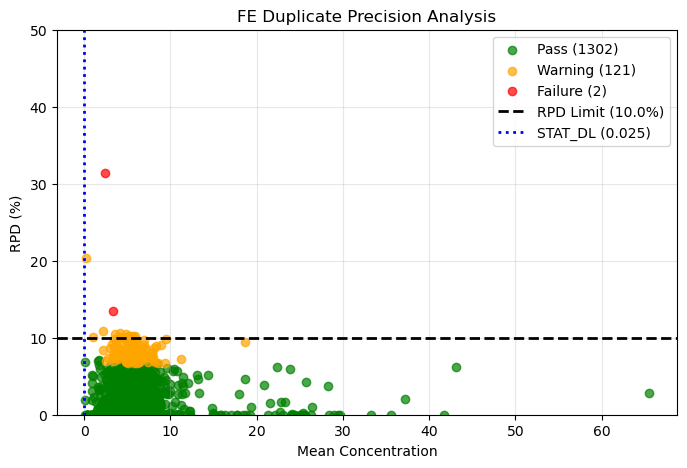


Analyte: SB
Total Points: 1956

Precision Status Counts:
PRECISION_STATUS
Pass       1682
Warning     256
Failure      18

STAT_DL_VALUE: 0.125
RPD Limit: 10


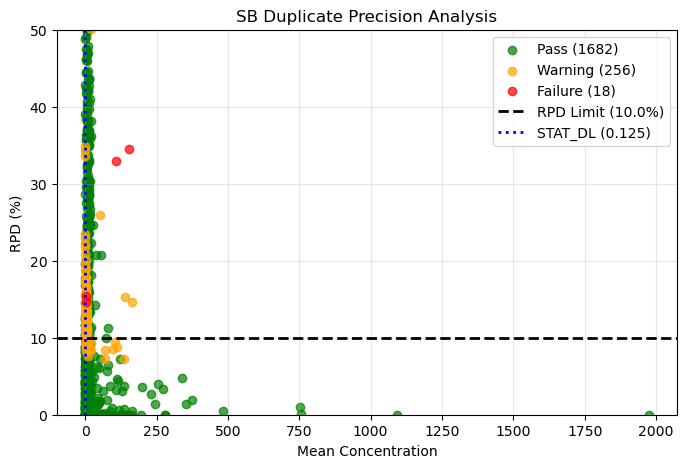


Analyte: CU
Total Points: 2132

Precision Status Counts:
PRECISION_STATUS
Pass       1856
Warning     199
Failure      77

STAT_DL_VALUE: 5.0
RPD Limit: 10


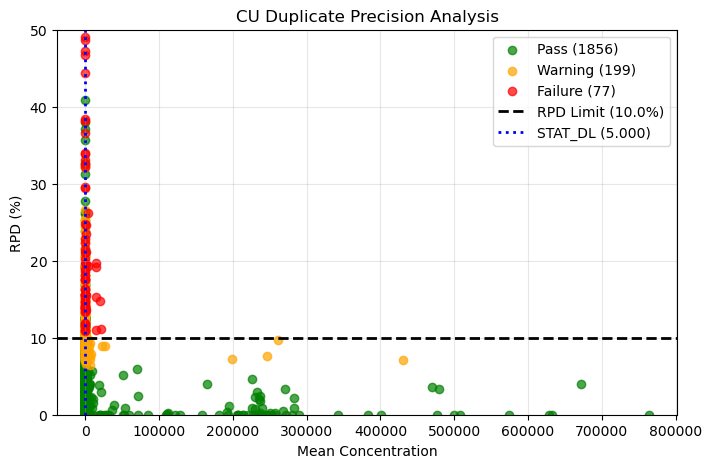


Analyte: K
Total Points: 454

Precision Status Counts:
PRECISION_STATUS
Pass       442
Warning      9
Failure      3

STAT_DL_VALUE: 0.025
RPD Limit: 10


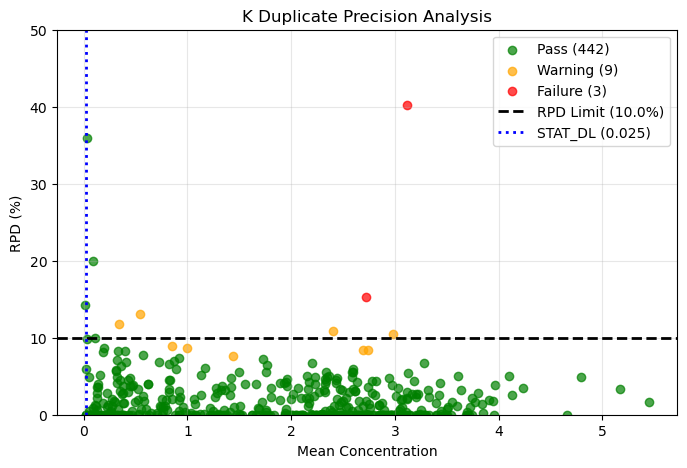


Analyte: P
Total Points: 388

Precision Status Counts:
PRECISION_STATUS
Pass       379
Warning      7
Failure      2

STAT_DL_VALUE: 0.025
RPD Limit: 10


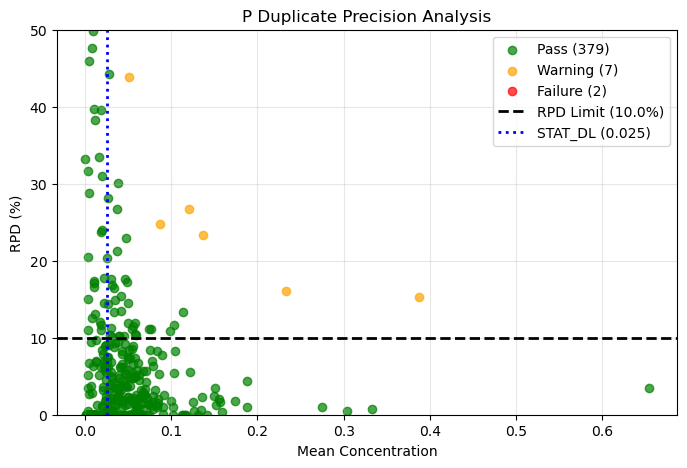


Analyte: AG
Total Points: 1992

Precision Status Counts:
PRECISION_STATUS
Pass       1820
Warning     156
Failure      16

STAT_DL_VALUE: 0.05
RPD Limit: 10


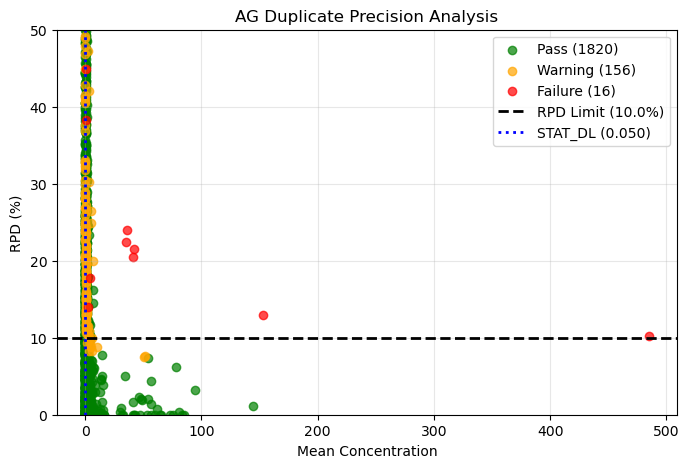


Analyte: AS
Total Points: 1991

Precision Status Counts:
PRECISION_STATUS
Pass       1650
Warning     261
Failure      80

STAT_DL_VALUE: 7.5
RPD Limit: 10


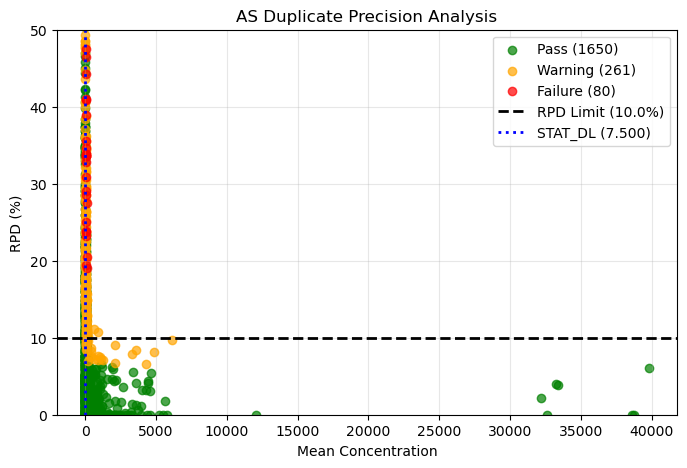

In [25]:
for analyte in analyte_list:

    print("\n" + "=" * 80)

    plot_analyte_rpd(
        df=df_replicates_model,
        analyte=analyte,
        include_ignore_failures=False,
        show_detection_limit=True,
        y_max=50
    )
    